# Torres de Hanói

Laboratorio de Inteligencia Artificial.

El trabajo recorre el problema en tres etapas. Primero se describe el juego y se calcula cuántos movimientos exige. Después se lo escribe en lógica formal, con predicados y una acción que tiene precondiciones y efectos. Por último se lo resuelve con algoritmos de búsqueda y se comparan los resultados.

Cada afirmación teórica tiene una celda que la comprueba sobre todos los estados, no sobre un caso de ejemplo.

Para ejecutarlo hace falta Python 3.10 o superior, matplotlib y pandas. Las celdas se ejecutan en orden.

## 1. El problema

El juego tiene tres postes, identificados como A, B y C, y $n$ discos de distinto tamaño. Los discos empiezan apilados en el poste A, de mayor a menor, y hay que trasladarlos todos al poste C. La tabla 1 reúne las tres reglas que limitan los movimientos.

| Regla | Enunciado |
|-------|-----------|
| R1 | Se mueve un disco por vez. |
| R2 | Solo se mueve el disco superior de un poste. |
| R3 | Un disco nunca queda sobre uno más pequeño. |

Tabla 1. Reglas del juego. Elaboración propia.

El juego fue publicado por Édouard Lucas en 1883 junto con una leyenda sobre un templo donde los monjes trasladaban 64 discos. Con esa cantidad la solución más corta tiene $2^{64}-1$ movimientos, así que la leyenda resultaba creíble.

### Cómo se representa un estado

La única información necesaria es en qué poste está cada disco. El orden dentro de un poste no se guarda, porque la regla R3 ya obliga a que los discos queden apilados de mayor a menor y ese orden se deduce de los tamaños.

Un estado queda descrito entonces por una tupla, donde la posición $i$ indica el poste del disco $i$ y el disco 0 es el más pequeño. La decisión tiene tres consecuencias prácticas: cualquier combinación de ceros, unos y doses describe una configuración legal, el total de estados es exactamente $3^n$, y el disco visible de un poste es el de índice más bajo que se encuentre en él. Al no existir estados inválidos, la búsqueda puede generar sucesores sin validarlos.

### Cuántos movimientos hacen falta

Para mover el disco más grande primero hay que dejar libre su poste de destino y apilar los $n-1$ discos restantes sobre el tercer poste. Recién ahí se puede mover el grande, y después hay que volver a montar esos $n-1$ discos encima. De esa descomposición sale la recurrencia

$$T(n) = 2\,T(n-1) + 1, \qquad T(1) = 1$$

cuya solución es $T(n) = 2^n - 1$. Ese valor es el mínimo posible y la estrategia descrita lo alcanza.

In [1]:
# Torres de Hanoi: estados y movimientos

from itertools import product # para recorrer todos los estados
from collections import deque # cola para BFS
import heapq # cola de prioridad para A*
import time # para medir cuanto tarda cada algoritmo
import pandas as pd # para la tabla de resultados
import matplotlib.pyplot as plt # para los dibujos

POSTES = [0, 1, 2]
NOMBRES = ["A", "B", "C"]

In [2]:
# estado[i] = poste del disco i. el disco 0 es el mas chico

def cima(estado): # disco visible de cada poste
    visibles = {}
    for disco in range(len(estado)):
        poste = estado[disco]
        if poste not in visibles: # el primero que aparece es el mas chico
            visibles[poste] = disco
    return visibles

def movimientos_posibles(estado): # los que permiten las reglas
    visibles = cima(estado)
    permitidos = []
    for origen in POSTES:
        if origen in visibles:
            disco = visibles[origen] # R2: solo el de arriba
            for destino in POSTES:
                if destino != origen and (destino not in visibles or disco < visibles[destino]): # R3
                    permitidos.append((disco, origen, destino))
    return permitidos

def mover(estado, movimiento): # estado que queda despues del movimiento
    disco, origen, destino = movimiento
    nuevo = list(estado)
    nuevo[disco] = destino
    return tuple(nuevo)

In [3]:
inicio = (0, 0, 0) # tres discos en A
meta = (2, 2, 2) # los tres en C

print("estado inicial:", inicio)
print("discos visibles:", cima(inicio))
print("movimientos posibles:")
for disco, origen, destino in movimientos_posibles(inicio):
    print("   disco", disco + 1, "de", NOMBRES[origen], "a", NOMBRES[destino],
          "->", mover(inicio, (disco, origen, destino)))

print("estados posibles:", 3 ** 3)
print("movimientos minimos:", 2 ** 3 - 1)

estado inicial: (0, 0, 0)
discos visibles: {0: 0}
movimientos posibles:
   disco 1 de A a B -> (1, 0, 0)
   disco 1 de A a C -> (2, 0, 0)
estados posibles: 27
movimientos minimos: 7


## 2. El juego en lógica formal

La sección anterior describe el juego con una estructura de datos. Esta lo describe con una teoría: un vocabulario de predicados, un conjunto de axiomas y una acción con precondiciones y efectos. Es la forma en que los planificadores clásicos representan un problema desde el trabajo de Fikes y Nilsson (1971).

### Vocabulario

Alcanzan tres predicados para describir cualquier configuración, según la tabla 2.

| Predicado | Lectura |
|-----------|---------|
| `sobre(x, y)` | el disco `x` está apoyado directamente sobre `y` |
| `libre(x)` | no hay ningún disco encima de `x` |
| `menor(x, y)` | `x` es más pequeño que `y` |

Tabla 2. Predicados de la teoría. Elaboración propia.

El segundo argumento de `sobre` puede ser un disco o un poste. Para no escribir dos casos distintos se adopta una convención: todo disco se considera menor que cualquier poste. Con eso, la situación "el poste está vacío" y la situación "el disco de abajo es más grande" quedan cubiertas por el mismo predicado.

### Axiomas

Un conjunto de átomos describe una configuración legal cuando cumple los cuatro axiomas de la tabla 3.

| | Axioma | Qué exige |
|---|--------|-----------|
| A1 | $\forall d\; \exists!\, y\;\; \mathrm{sobre}(d, y)$ | cada disco está apoyado en un solo lugar |
| A2 | $\mathrm{sobre}(y, x) \wedge \mathrm{sobre}(z, x) \rightarrow y = z$ | sobre cada objeto hay a lo sumo un disco |
| A3 | $\mathrm{sobre}(x, y) \rightarrow \mathrm{menor}(x, y)$ | siempre el más pequeño arriba, que es R3 |
| A4 | $\mathrm{libre}(x) \leftrightarrow \neg\exists y\;\; \mathrm{sobre}(y, x)$ | definición de `libre` |

Tabla 3. Axiomas de integridad. Elaboración propia.

No hace falta un axioma que prohíba las torres circulares. Si por A3 cada disco es más pequeño que el que tiene debajo, ningún disco puede terminar apoyado sobre sí mismo.

### La acción

La tabla 4 define el operador $\mathrm{mover}(d, x, y)$, que traslada el disco $d$ desde el objeto $x$ hacia el objeto $y$.

| | Fórmula |
|---|---|
| Precondición | $\mathrm{libre}(d) \wedge \mathrm{sobre}(d, x) \wedge \mathrm{libre}(y) \wedge \mathrm{menor}(d, y) \wedge x \neq y$ |
| Agrega | $\mathrm{sobre}(d, y)$, $\mathrm{libre}(x)$ |
| Quita | $\mathrm{sobre}(d, x)$, $\mathrm{libre}(y)$ |

Tabla 4. Operador de acción. Elaboración propia.

Las reglas del juego quedan repartidas entre la forma del operador y dos de sus literales. R1 está en la forma, porque la acción mueve un disco y no un grupo. R2 es el literal $\mathrm{libre}(d)$. R3 es el literal $\mathrm{menor}(d, y)$. Todo átomo que no aparece entre los efectos conserva su valor.

### Estado inicial y meta

$$I = \{\mathrm{sobre}(d_n, A)\} \cup \{\mathrm{sobre}(d_i, d_{i+1})\} \cup \{\mathrm{libre}(d_1), \mathrm{libre}(B), \mathrm{libre}(C)\}$$

$$G = \mathrm{sobre}(d_n, C) \wedge \bigwedge_{i<n} \mathrm{sobre}(d_i, d_{i+1})$$

Resolver el juego consiste en encontrar una secuencia de instancias de $\mathrm{mover}$ que lleve de $I$ a $G$.

Las celdas que siguen traducen cada estado a sus átomos y comprueban dos propiedades: que se cumplan los axiomas y que la precondición genere exactamente los mismos movimientos que `movimientos_posibles`.

In [4]:
# el mismo estado, escrito como atomos de la teoria

def nombre_disco(disco):
    return "disco " + str(disco + 1)

def es_disco(objeto):
    return objeto.startswith("disco")

def tamanio(objeto): # el poste cuenta como el objeto mas grande de todos
    return int(objeto.split()[1]) if es_disco(objeto) else 99

def menor(x, y):
    return es_disco(x) and tamanio(x) < tamanio(y)

def hechos(estado): # devuelve los atomos sobre(x, y) y libre(x)
    sobre = []
    libre = []
    for poste in POSTES:
        pila = sorted([d for d in range(len(estado)) if estado[d] == poste])
        debajo = "poste " + NOMBRES[poste]
        for disco in reversed(pila): # desde la base hacia arriba
            sobre.append((nombre_disco(disco), debajo))
            debajo = nombre_disco(disco)
        libre.append(debajo) # la cima, o el poste si quedo vacio
    return sobre, libre

In [5]:
# la precondicion de mover, escrita literal como la formula

def precondicion(sobre, libre, disco, origen, destino):
    return (disco in libre                  # R2: nada encima del disco
            and (disco, origen) in sobre    # el disco esta sobre el origen
            and destino in libre            # el destino esta despejado
            and menor(disco, destino)       # R3: no va sobre uno mas chico
            and origen != destino)

def movimientos_logicos(estado): # los que cumplen la precondicion
    sobre, libre = hechos(estado)
    encontrados = []
    for disco, origen in sobre: # A1: cada disco esta sobre un solo objeto
        for destino in libre:
            if precondicion(sobre, libre, disco, origen, destino):
                encontrados.append((disco, origen, destino))
    return encontrados

def cumple_axiomas(sobre, libre, n):
    discos = [x for x, y in sobre]
    soportes = [y for x, y in sobre]
    a1 = len(discos) == len(set(discos)) == n   # cada disco en un solo lugar
    a2 = len(soportes) == len(set(soportes))    # un solo disco sobre cada objeto
    a3 = all(menor(x, y) for x, y in sobre)     # siempre el mas chico arriba
    a4 = all(x not in soportes for x in libre)  # libre = nada encima
    return a1 and a2 and a3 and a4

In [6]:
ejemplo = (0, 1, 1) # disco 1 en A, discos 2 y 3 en B
sobre, libre = hechos(ejemplo)

print("estado:", ejemplo)
print("\natomos sobre:")
for x, y in sobre:
    print("   sobre(" + x + ", " + y + ")")
print("\natomos libre:")
for x in libre:
    print("   libre(" + x + ")")
print("\ncumple los axiomas:", cumple_axiomas(sobre, libre, len(ejemplo)))
print("\nmover que cumplen la precondicion:")
for disco, origen, destino in movimientos_logicos(ejemplo):
    print("   mover(" + disco + ", " + origen + ", " + destino + ")")

estado: (0, 1, 1)

atomos sobre:
   sobre(disco 1, poste A)
   sobre(disco 3, poste B)
   sobre(disco 2, disco 3)

atomos libre:
   libre(disco 1)
   libre(disco 2)
   libre(poste C)

cumple los axiomas: True

mover que cumplen la precondicion:
   mover(disco 1, poste A, disco 2)
   mover(disco 1, poste A, poste C)
   mover(disco 2, disco 3, poste C)


In [7]:
# comprobacion: la logica y el codigo tienen que dar lo mismo en TODOS los estados

def poste_del_objeto(objeto, estado): # pasa un atomo a numero de poste
    if es_disco(objeto):
        return estado[tamanio(objeto) - 1]
    return NOMBRES.index(objeto.split()[1])

for n in [1, 2, 3, 4, 5]:
    for estado in product(POSTES, repeat=n):
        sobre, libre = hechos(estado)
        assert cumple_axiomas(sobre, libre, n)
        logicos = set((tamanio(d) - 1, poste_del_objeto(o, estado), poste_del_objeto(t, estado))
                      for d, o, t in movimientos_logicos(estado))
        assert logicos == set(movimientos_posibles(estado))
    print("n =", n, "->", 3 ** n, "estados: axiomas y precondicion verificados")

n = 1 -> 3 estados: axiomas y precondicion verificados
n = 2 -> 9 estados: axiomas y precondicion verificados
n = 3 -> 27 estados: axiomas y precondicion verificados
n = 4 -> 81 estados: axiomas y precondicion verificados
n = 5 -> 243 estados: axiomas y precondicion verificados


La comprobación recorre los $3^n$ estados en lugar de un ejemplo suelto, y deja dos resultados. Por un lado, ninguna tupla de la representación describe una configuración ilegal, así que la búsqueda puede generar estados sin validarlos. Por otro, `movimientos_posibles` calcula lo mismo que la precondición, pero mirando tres postes en vez de recorrer pares de objetos.

## 3. Los algoritmos de búsqueda

Para aplicar un algoritmo hay que expresar el juego con los componentes habituales de un problema de búsqueda (Russell y Norvig, 2021). La tabla 5 los detalla.

| Componente | En este problema |
|------------|------------------|
| Estados | las $3^n$ tuplas |
| Acciones | lo que devuelve `movimientos_posibles` |
| Sucesor | `mover(estado, movimiento)` |
| Costo | 1 por movimiento |
| Inicio | `(0, 0, ..., 0)` |
| Meta | `(2, 2, ..., 2)` |

Tabla 5. El juego como problema de búsqueda. Elaboración propia.

Como todos los movimientos cuestan lo mismo, el camino más corto coincide con la solución de menos movimientos.

Se comparan tres estrategias: búsqueda en anchura (breadth first search, BFS), búsqueda en profundidad (depth first search, DFS) y A\*. Las tres comparten casi todo el código. Guardan en un diccionario de dónde vino cada estado, cuentan los nodos que expanden y registran el tamaño máximo de la frontera. La diferencia está en un solo punto: de dónde sale el próximo estado. BFS lo toma del principio de una cola, DFS del final de una pila y A\* del menor valor de $f$.

In [8]:
# funciones que usan los tres algoritmos

def camino(padre, estado): # rearma la lista de movimientos hacia atras
    pasos = []
    while padre[estado] is not None:
        anterior, movimiento = padre[estado]
        pasos.append(movimiento)
        estado = anterior
    pasos.reverse()
    return pasos

def resultado(nombre, padre, meta, expandidos, frontera, reloj):
    pasos = camino(padre, meta)
    return {"algoritmo": nombre, "pasos": pasos, "movimientos": len(pasos),
            "expandidos": expandidos, "frontera": frontera,
            "ms": round((time.perf_counter() - reloj) * 1000, 1)}

def es_valida(inicio, pasos, meta): # revisa que cada paso sea legal
    actual = inicio
    for movimiento in pasos:
        if movimiento not in movimientos_posibles(actual):
            return False
        actual = mover(actual, movimiento)
    return actual == meta

### Búsqueda en anchura

La frontera es una cola, de manera que el primer estado en entrar es el primero en salir. El recorrido avanza por niveles de profundidad, así que el primer camino que llega a un estado resulta ser el más corto. El algoritmo es completo y óptimo. El precio lo paga en memoria, porque guarda todos los estados vistos.

In [9]:
def bfs(inicio, meta):
    reloj = time.perf_counter()
    padre = {inicio: None}
    cola = deque([inicio]) # el primero que entra es el primero que sale
    expandidos = 0
    frontera = 1
    while cola:
        actual = cola.popleft()
        expandidos += 1
        if actual == meta:
            break
        for movimiento in movimientos_posibles(actual):
            vecino = mover(actual, movimiento)
            if vecino not in padre: # si ya lo vimos, el camino viejo es mas corto
                padre[vecino] = (actual, movimiento)
                cola.append(vecino)
        frontera = max(frontera, len(cola))
    return resultado("BFS", padre, meta, expandidos, frontera, reloj)

### Búsqueda en profundidad

El código es el mismo salvo por la frontera, que ahora es una pila y devuelve el último estado que entró. La búsqueda sigue una rama hasta agotarla antes de probar otra. Sigue siendo completa, porque el grafo es finito y se anotan los estados visitados, pero pierde la optimalidad: encuentra una solución, no la más corta.

In [10]:
def dfs(inicio, meta):
    reloj = time.perf_counter()
    padre = {inicio: None}
    pila = [inicio] # el ultimo que entra es el primero que sale
    visitados = set()
    expandidos = 0
    frontera = 1
    while pila:
        actual = pila.pop()
        if actual in visitados:
            continue
        visitados.add(actual)
        expandidos += 1
        if actual == meta:
            break
        for movimiento in movimientos_posibles(actual):
            vecino = mover(actual, movimiento)
            if vecino not in padre:
                padre[vecino] = (actual, movimiento)
                pila.append(vecino)
        frontera = max(frontera, len(pila))
    return resultado("DFS", padre, meta, expandidos, frontera, reloj)

### A\* y las dos heurísticas

A\* saca de la frontera el estado con menor $f = g + h$, donde $g$ es lo que ya costó llegar y $h$ estima lo que falta (Hart, Nilsson y Raphael, 1968). Cuando $h$ nunca sobreestima la distancia real se dice que es admisible, y en ese caso la solución encontrada es óptima.

Se prueban dos heurísticas de calidad muy distinta, para separar el efecto del algoritmo del efecto de la estimación.

La primera, $h_1$, cuenta los discos que no están en su poste final. Es admisible porque cada disco mal ubicado necesita al menos un movimiento propio. Su limitación es el techo: $h_1$ nunca supera $n$, mientras la distancia real puede llegar a $2^n-1$.

La segunda, $h_2$, recorre los discos del más grande al más pequeño. Si un disco ya está en su poste objetivo no aporta nada. Si no lo está, hay que sacarle de encima los discos menores, lo que cuesta al menos $2^{k}-1$ movimientos, y después moverlo, de modo que aporta $2^{k}$ y los menores pasan a tener como objetivo el tercer poste. El cálculo no estima: devuelve la cantidad exacta de movimientos que faltan hasta la torre completa (Hinz, Klavžar, Milutinović y Petr, 2013). La celda de verificación lo contrasta contra las distancias reales.

In [11]:
def h1(estado, meta): # discos que no estan en su poste final
    return sum(1 for disco in range(len(estado)) if estado[disco] != meta[disco])

def h2(estado, poste_meta): # movimientos exactos que faltan
    total = 0
    objetivo = poste_meta
    for disco in reversed(range(len(estado))): # del mas grande al mas chico
        if estado[disco] != objetivo:
            total += 2 ** disco # sacar los de encima y mover este
            objetivo = 3 - estado[disco] - objetivo # los chicos van al tercer poste
    return total

In [12]:
# verificacion: h2 tiene que dar la distancia real, y h1 nunca pasarse

def distancias_reales(meta): # BFS al reves desde la meta
    distancia = {meta: 0}
    cola = deque([meta])
    while cola:
        actual = cola.popleft()
        for movimiento in movimientos_posibles(actual):
            vecino = mover(actual, movimiento)
            if vecino not in distancia:
                distancia[vecino] = distancia[actual] + 1
                cola.append(vecino)
    return distancia

for n in [3, 4, 5, 6]:
    final = tuple([2] * n)
    distancia = distancias_reales(final)
    exacta = all(h2(estado, 2) == d for estado, d in distancia.items())
    admisible = all(h1(estado, final) <= d for estado, d in distancia.items())
    print("n =", n, "->", len(distancia), "estados alcanzados |",
          "h2 exacta:", exacta, "| h1 admisible:", admisible,
          "| distancia maxima:", max(distancia.values()))

n = 3 -> 27 estados alcanzados | h2 exacta: True | h1 admisible: True | distancia maxima: 7
n = 4 -> 81 estados alcanzados | h2 exacta: True | h1 admisible: True | distancia maxima: 15
n = 5 -> 243 estados alcanzados | h2 exacta: True | h1 admisible: True | distancia maxima: 31
n = 6 -> 729 estados alcanzados | h2 exacta: True | h1 admisible: True | distancia maxima: 63


El recorrido inverso alcanza los $3^n$ estados, lo que confirma que desde cualquier configuración se puede llegar a cualquier otra. La distancia más larga es $2^n-1$ y corresponde al trayecto entre dos torres completas.

In [13]:
def a_estrella(inicio, meta, h, nombre):
    reloj = time.perf_counter()
    padre = {inicio: None}
    costo = {inicio: 0} # g: movimientos hechos hasta cada estado
    cola = [(h(inicio), 0, inicio)] # ordenada por f = g + h
    visitados = set()
    expandidos = 0
    frontera = 1
    orden = 0 # desempata cuando dos estados tienen el mismo f
    while cola:
        actual = heapq.heappop(cola)[2]
        if actual in visitados:
            continue
        visitados.add(actual)
        expandidos += 1
        if actual == meta:
            break
        for movimiento in movimientos_posibles(actual):
            vecino = mover(actual, movimiento)
            nuevo = costo[actual] + 1
            if nuevo < costo.get(vecino, 10 ** 9): # llegamos por un camino mas corto
                costo[vecino] = nuevo
                padre[vecino] = (actual, movimiento)
                orden += 1
                heapq.heappush(cola, (nuevo + h(vecino), orden, vecino))
        frontera = max(frontera, len(cola))
    return resultado(nombre, padre, meta, expandidos, frontera, reloj)

### La solución recursiva

La estrategia clásica no busca. Aplica la misma descomposición que justifica la recurrencia de la sección 1: para trasladar $n$ discos mueve $n-1$ al poste auxiliar, lleva el más grande al destino y vuelve a apilar los $n-1$ encima. Sirve como referencia para confirmar que los algoritmos llegan al mismo largo.

In [14]:
def recursiva(n, origen, destino, auxiliar):
    if n == 0:
        return []
    return (recursiva(n - 1, origen, auxiliar, destino)   # los chicos al auxiliar
            + [(n - 1, origen, destino)]                  # el grande al destino
            + recursiva(n - 1, auxiliar, destino, origen)) # los chicos encima

def resolver(n): # corre los cuatro algoritmos sobre el mismo problema
    inicio = tuple([0] * n)
    meta = tuple([2] * n)
    return [bfs(inicio, meta),
            dfs(inicio, meta),
            a_estrella(inicio, meta, lambda e: h1(e, meta), "A* h1"),
            a_estrella(inicio, meta, lambda e: h2(e, 2), "A* h2")]

In [15]:
inicio = (0, 0, 0)
meta = (2, 2, 2)
pasos = recursiva(3, 0, 2, 1)

print("recursiva:", len(pasos), "movimientos | valida:", es_valida(inicio, pasos, meta))
for r in resolver(3):
    print(r["algoritmo"], "->", r["movimientos"], "movimientos | valida:",
          es_valida(inicio, r["pasos"], meta))

print("\nsolucion optima paso a paso:")
for numero, (disco, origen, destino) in enumerate(pasos, start=1):
    print(" ", str(numero) + ".", "disco", disco + 1, "de", NOMBRES[origen], "a", NOMBRES[destino])

recursiva: 7 movimientos | valida: True
BFS -> 7 movimientos | valida: True
DFS -> 9 movimientos | valida: True
A* h1 -> 7 movimientos | valida: True
A* h2 -> 7 movimientos | valida: True

solucion optima paso a paso:
  1. disco 1 de A a C
  2. disco 2 de A a B
  3. disco 1 de C a B
  4. disco 3 de A a C
  5. disco 1 de B a A
  6. disco 2 de B a C
  7. disco 1 de A a C


## 4. Comparación

Los cuatro algoritmos resuelven el mismo problema con $n$ entre 3 y 10. Se mide el trabajo de búsqueda por los nodos expandidos, la memoria por el tamaño máximo de la frontera y la calidad por el largo de la solución. La tabla 6 reúne las medidas, la tabla 7 concentra la columna de nodos expandidos y la figura 1 grafica las dos comparaciones.

In [16]:
filas = []
for n in range(3, 11):
    for r in resolver(n):
        filas.append({"n": n, "algoritmo": r["algoritmo"], "movimientos": r["movimientos"],
                      "optimo": 2 ** n - 1, "expandidos": r["expandidos"],
                      "frontera": r["frontera"], "ms": r["ms"]})

tabla = pd.DataFrame(filas)
tabla

,n,algoritmo,movimientos,optimo,expandidos,frontera,ms
0,3,BFS,7,7,25,8,0.1
1,3,DFS,9,7,10,6,0.0
2,3,A* h1,7,7,18,6,0.1
3,3,A* h2,7,7,8,5,0.0
4,4,BFS,15,15,71,16,0.2
5,4,DFS,29,15,43,15,0.1
6,4,A* h1,15,15,54,8,0.3
7,4,A* h2,15,15,16,9,0.1
8,5,BFS,31,31,233,32,0.7
9,5,DFS,81,31,82,42,0.3


Tabla 6. Medidas de los cuatro algoritmos para $n$ de 3 a 10. Elaboración propia.

In [17]:
expandidos = tabla.pivot(index="n", columns="algoritmo", values="expandidos")
expandidos["espacio 3^n"] = [3 ** n for n in expandidos.index]
expandidos

algoritmo,A* h1,A* h2,BFS,DFS,espacio 3^n
n,,,,,
3,18,8,25,10,27
4,54,16,71,43,81
5,178,32,233,82,243
6,586,64,687,367,729
7,1866,128,2145,730,2187
8,5866,256,6391,3283,6561
9,18202,512,19513,6562,19683
10,55882,1024,58367,29527,59049


Tabla 7. Nodos expandidos frente al tamaño del espacio de estados. Elaboración propia.

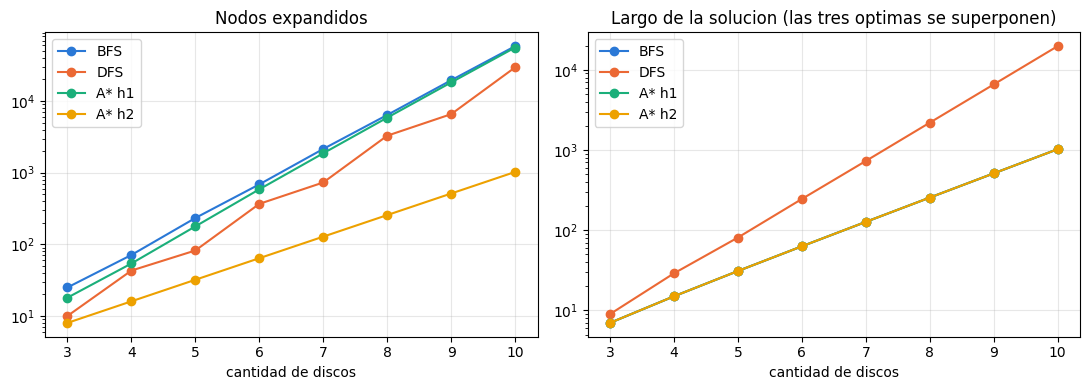

In [18]:
COLORES = {"BFS": "#2a78d6", "DFS": "#eb6834", "A* h1": "#1baf7a", "A* h2": "#eda100"}

fig, (izq, der) = plt.subplots(1, 2, figsize=(11, 4))
for algoritmo in COLORES:
    datos = tabla[tabla["algoritmo"] == algoritmo]
    izq.plot(datos["n"], datos["expandidos"], color=COLORES[algoritmo], marker="o", label=algoritmo)
    der.plot(datos["n"], datos["movimientos"], color=COLORES[algoritmo], marker="o", label=algoritmo)

izq.set_title("Nodos expandidos")
der.set_title("Largo de la solucion (las tres optimas se superponen)")
for eje in [izq, der]:
    eje.set_yscale("log") # si no, las diferencias no se ven
    eje.set_xlabel("cantidad de discos")
    eje.grid(alpha=0.3)
    eje.legend()
plt.tight_layout()
plt.show()

Figura 1. Nodos expandidos y largo de la solución, en escala logarítmica. Elaboración propia.

### Lectura de los resultados

BFS recorre casi todo el espacio. Con diez discos expande 58 367 de los 59 049 estados que existen. Encuentra la solución óptima, pero paga el espacio entero para hacerlo.

A\* con $h_1$ expande apenas unos miles de nodos menos. El motivo está en la escala de la heurística, que nunca pasa de $n$ mientras la distancia real llega a $2^n-1$. Una estimación admisible garantiza que la solución sea óptima, no que la búsqueda sea rápida.

Con $h_2$ el panorama cambia de orden de magnitud. Al ser exacta, todos los estados del camino óptimo comparten el mismo valor de $f$ y el resto queda por encima, así que A\* expande solo ese camino: $2^n$ nodos. Con diez discos son 1 024 contra los 58 367 de BFS.

DFS devuelve una solución, no la solución. Expande alrededor de la mitad de los nodos que BFS y entrega 19 685 movimientos donde el óptimo es 1 023. Tampoco ahorra memoria en este problema, porque arrastra los sucesores pendientes de una rama que recorre casi todo el grafo: su pila llega a 9 843 entradas frente a las 1 024 de la cola de BFS. La fama de DFS como algoritmo barato en memoria supone ramas largas y angostas, y el grafo de Hanói no tiene esa forma.

Ninguno de los cuatro escapa del tamaño de la respuesta. Aunque A\* con $h_2$ no expanda un solo nodo de más, el camino sigue teniendo $2^n-1$ movimientos. La búsqueda informada ahorra exploración, no largo de solución.

## 5. Representación gráfica

La figura 2 muestra la solución de tres discos paso a paso, con el tamaño del disco codificado en la intensidad del color.

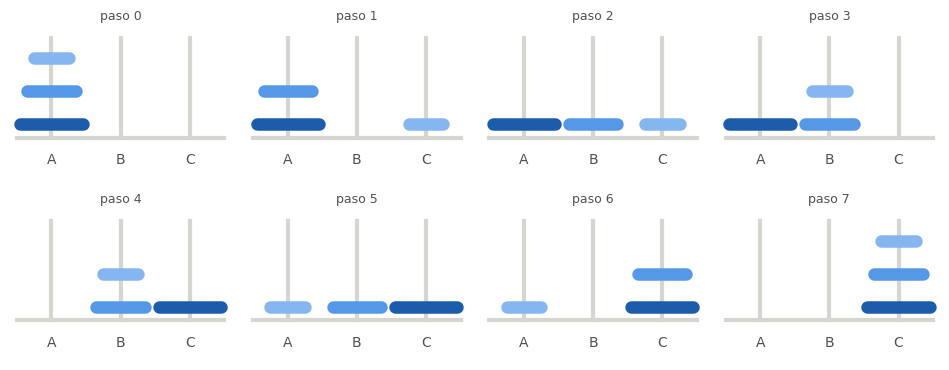

In [19]:
AZULES = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"] # mas grande, mas oscuro

def dibujar(ax, estado, titulo=""):
    n = len(estado)
    for poste in POSTES:
        ax.plot([poste, poste], [0, n], color="#d6d5d0", linewidth=3) # el palo
        ax.text(poste, -0.8, NOMBRES[poste], ha="center", color="#52514e")
    ax.plot([-0.5, 2.5], [0, 0], color="#d6d5d0", linewidth=3) # la base
    for poste in POSTES:
        pila = sorted([d for d in range(n) if estado[d] == poste], reverse=True)
        for nivel, disco in enumerate(pila): # de la base hacia arriba
            ancho = 0.15 + 0.3 * (disco + 1) / n
            color = AZULES[disco * len(AZULES) // n]
            ax.plot([poste - ancho, poste + ancho], [nivel + 0.4, nivel + 0.4],
                    color=color, linewidth=9, solid_capstyle="round")
    ax.set_xlim(-0.6, 2.6)
    ax.set_ylim(-1.2, n + 0.3)
    ax.set_title(titulo, fontsize=9, color="#52514e")
    ax.axis("off")

def dibujar_pasos(inicio, pasos, columnas=4):
    estados = [inicio]
    for movimiento in pasos:
        estados.append(mover(estados[-1], movimiento))
    filas = -(-len(estados) // columnas) # division redondeando para arriba
    fig, ejes = plt.subplots(filas, columnas, figsize=(2.4 * columnas, 1.9 * filas))
    for i, eje in enumerate(ejes.flat):
        if i < len(estados):
            dibujar(eje, estados[i], "paso " + str(i))
        else:
            eje.axis("off")
    plt.tight_layout()
    plt.show()

optima = bfs((0, 0, 0), (2, 2, 2)) # la solucion de 3 discos
dibujar_pasos((0, 0, 0), optima["pasos"])

Figura 2. Solución óptima para tres discos. Elaboración propia.

### El grafo de estados

Si se dibujan los $3^n$ estados y se unen los que están a un movimiento de distancia, aparece un triángulo de Sierpiński. La posición de cada estado se obtiene por recursión: el disco más grande elige uno de los tres triángulos menores, el siguiente elige dentro de ese, y así hasta el más pequeño, de modo que cada disco pesa el doble que el inmediatamente menor.

Los tres vértices corresponden a las torres completas. El largo de una arista indica qué disco se mueve, y las tres que cruzan el centro son movimientos del disco mayor, así que la solución óptima cruza una sola. La figura 3 lo muestra para tres, cuatro y cinco discos.

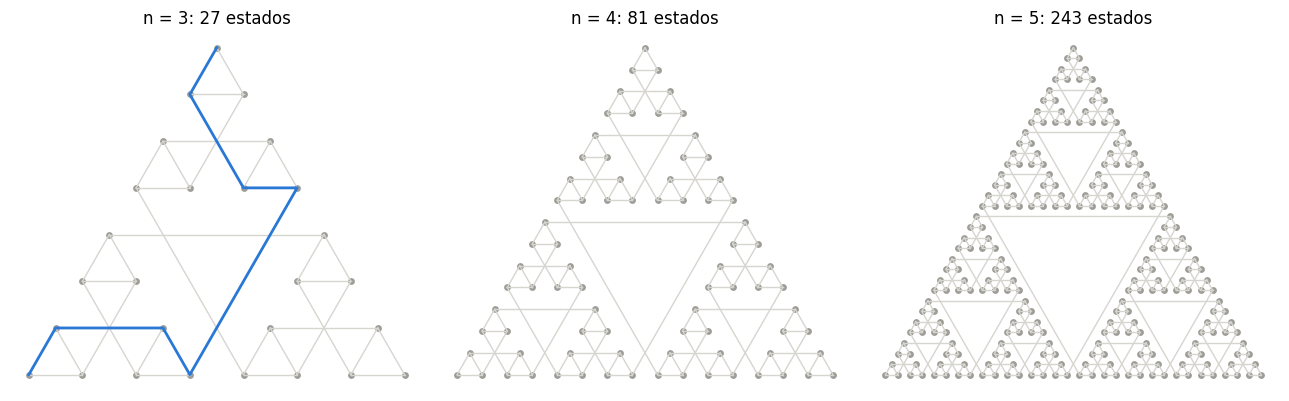

In [20]:
def posicion(estado): # donde va el estado en el triangulo
    vertices = [(0, 0), (1, 0), (0.5, 0.87)]
    x = y = 0
    escala = 0.5
    for disco in reversed(range(len(estado))): # del mas grande al mas chico
        x += escala * vertices[estado[disco]][0]
        y += escala * vertices[estado[disco]][1]
        escala = escala / 2
    return x, y

def dibujar_grafo(ax, n, camino_estados=None):
    puntos = {estado: posicion(estado) for estado in product(POSTES, repeat=n)}
    for estado in puntos:
        for movimiento in movimientos_posibles(estado):
            vecino = mover(estado, movimiento)
            if estado < vecino: # cada arista una sola vez
                ax.plot([puntos[estado][0], puntos[vecino][0]],
                        [puntos[estado][1], puntos[vecino][1]], color="#d6d5d0", linewidth=1)
    ax.scatter([p[0] for p in puntos.values()], [p[1] for p in puntos.values()],
               s=15, color="#9d9c96")
    if camino_estados:
        ax.plot([puntos[e][0] for e in camino_estados], [puntos[e][1] for e in camino_estados],
                color="#2a78d6", linewidth=2)
    ax.set_title("n = " + str(n) + ": " + str(3 ** n) + " estados")
    ax.set_aspect("equal")
    ax.axis("off")

recorrido = [(0, 0, 0)] # los estados por los que pasa la solucion
for movimiento in optima["pasos"]:
    recorrido.append(mover(recorrido[-1], movimiento))

fig, ejes = plt.subplots(1, 3, figsize=(13, 4.2))
dibujar_grafo(ejes[0], 3, recorrido)
dibujar_grafo(ejes[1], 4)
dibujar_grafo(ejes[2], 5)
plt.tight_layout()
plt.show()

Figura 3. Espacio de estados para tres, cuatro y cinco discos, con la solución óptima marcada en el primero. Elaboración propia.

## 6. Conclusiones

La representación elegida determina cuánto trabajo queda después. Guardar únicamente el poste de cada disco convierte a las $3^n$ tuplas en configuraciones legales, y la regla R3 deja de ser una validación en tiempo de ejecución para volverse una propiedad de la estructura de datos.

La formalización lógica funciona como puente entre el enunciado y el código. Las tres reglas se reparten entre la forma del operador y dos literales de su precondición, y esa precondición es la función sucesora que usan los algoritmos. El trabajo no da por sentada la traducción: la comprueba sobre todos los estados hasta cinco discos.

En los resultados pesa más la calidad de la heurística que la elección del algoritmo. BFS y A\* con $h_1$ expanden cantidades del mismo orden, mientras A\* con $h_2$ baja dos órdenes de magnitud, y las tres búsquedas garantizan optimalidad. Lo que las separa es cuánta información aporta $h$.

Las ventajas que suelen atribuirse a cada algoritmo dependen de la forma del grafo. En Hanói, DFS no ahorra memoria y entrega soluciones del orden de $3^{n-1}$ movimientos, bastante lejos del óptimo.

Queda una observación sobre el problema en sí. La versión recursiva produce la secuencia óptima sin explorar nada, porque Hanói tiene solución cerrada. Cuando existe una fórmula demostrada, la búsqueda sirve para estudiar el espacio de estados y comparar estrategias, no para resolver el caso concreto.

## 7. Referencias

Fikes, R. E. y Nilsson, N. J. (1971). STRIPS: A new approach to the application of theorem proving to problem solving. *Artificial Intelligence*, 2(3-4), 189-208.

Hart, P. E., Nilsson, N. J. y Raphael, B. (1968). A formal basis for the heuristic determination of minimum cost paths. *IEEE Transactions on Systems Science and Cybernetics*, 4(2), 100-107.

Hinz, A. M., Klavžar, S., Milutinović, U. y Petr, C. (2013). *The Tower of Hanoi: Myths and Maths*. Birkhäuser.

Lucas, É. (1883). *Récréations mathématiques* (vol. 3). Gauthier-Villars.

Russell, S. y Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4.ª ed.). Pearson.